In [10]:
library(dplyr)
library(ggplot2)
library(brms)
library(janitor)
library(BH)
library(rjags)

In [2]:
#Both metabolic_rate - minimum and maximum are all NA values, useless
#Sex column may be useless, 227 rows are empty in dataset 1 and 900 in dataset 2

In [3]:
file <- 'dataset.csv'
df <- read.csv(file) %>% clean_names()
#colnames(df)
relevant_features = c("phylum", "class", "order", "genus", "species","sex", "sample_size_value", "body_mass", "body_mass_units", "metabolic_rate", "metabolic_rate_units", "metabolic_rate_method")
dataset = df[relevant_features]

### Extended dataset

In [4]:
#Extended dataset
#data_clean_2 <- dataset %>% 
#                filter(!is.na(metabolic_rate), !is.na(body_mass))
#data_2_classes <- n_distinct(data_clean_2$class)
#data_2_order <- n_distinct(data_clean_2$order)
#data_2_genus <- n_distinct(data_clean_2$genus)
#data_2_species <- n_distinct(data_clean_2$species)
#
#cat("Dataset 2 contains", data_2_classes, "distinct classes", data_2_order, "distinct orders", data_2_genus, "distinct genera, and", data_2_species, "distinct species.\n")
#
#table(data_clean_2$class, data_clean_2$metabolic_rate_method)
#
#ggplot(data_clean_2, 
#        aes(x=body_mass, y=metabolic_rate, colour=class)
#      ) + geom_point() + scale_x_log10() + scale_y_log10() +
#        labs(x="mass (kg)", y="metabolic rate (W)", title="Dataset 2 - Body mass vs metabolic rate", colour="Class")


### Restricted dataset

In [5]:
# cleaning data
data <- dataset[dataset$metabolic_rate_method=="basal metabolic rate",] %>% 
                filter(!is.na(metabolic_rate), !is.na(body_mass))
classes <- n_distinct(data$class)
orders <- n_distinct(data$order)
genera <- n_distinct(data$genus)
species <- n_distinct(data$species)

# log-log transform: calcoliamo i logaritmi usando i nomi colonna puliti
data$log_mass <- log(data$body_mass)     # log body mass (kg)
data$log_rate <- log(data$metabolic_rate) # log metabolic rate (W)

cat("Dataset 1 contains", classes, "distinct classes", orders, "distinct orders", genera, "distinct genera, and", species, "distinct species.\n")

cat("These are the relevant columns:", colnames(dataset))

Dataset 1 contains 2 distinct classes 29 distinct orders 172 distinct genera, and 233 distinct species.
These are the relevant columns: phylum class order genus species sex sample_size_value body_mass body_mass_units metabolic_rate metabolic_rate_units metabolic_rate_method

In [6]:
#CHECK NA VALUES
sum(is.na(data))
#CHECK UNITS
sum(data$body_mass_units == "kg") == nrow(data)
sum(data$metabolic_rate_units == "W") == nrow(data)
#sum(data$sex == "")
#max(data$body_mass)
#data[data$body_mass == 115,]


[1] 0

[1] TRUE

[1] TRUE

In [7]:
table(data$class, data$metabolic_rate_method)

          
           basal metabolic rate
  Aves                      133
  Mammalia                  146

## 1. Plot metabolic rate versus body mass on log–log axes, distinguishing the main taxonomic groups.

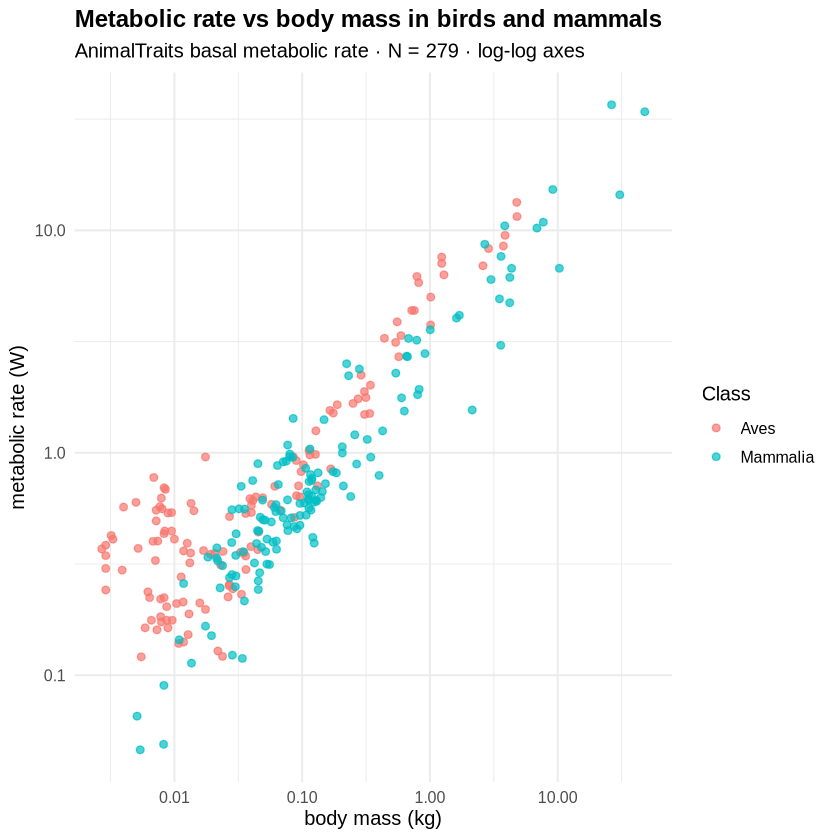

In [8]:
p_scatter <- ggplot(data, aes(x=body_mass, y=metabolic_rate, colour=class)) + 
                geom_point(alpha=0.7, size=1.8) + 
                scale_x_log10() + scale_y_log10() +
                labs(x="body mass (kg)",
                     y="metabolic rate (W)", 
                     title="Metabolic rate vs body mass in birds and mammals",
                     subtitle = "AnimalTraits basal metabolic rate \u00b7 N = 279 \u00b7 log-log axes",
                     colour="Class") +
                theme_minimal(base_size = 12) +
                theme(plot.title = element_text(face = "bold"))

print(p_scatter)
ggsave("q1_rate_vs_mass_plot.pdf", p_scatter, width = 8, height = 5)

In [12]:
cat("Dataset 1 has", nrow(data), "elements.\n")
cat("It contains", classes, "distinct classes, which are", unique(data$class), ".\n")
cat("It has also", orders, "distinct orders", genera, "distinct genera, and", species, "distinct species.\n")

Dataset 1 has 279 elements.
It contains 2 distinct classes, which are Aves Mammalia .
It has also 29 distinct orders 172 distinct genera, and 233 distinct species.


In [13]:
unique_species <- data %>% count(class, species, sort=TRUE)

In [14]:
which_class <- unique_species %>% filter(n>1) %>% count(class)

In [15]:
which_class

class,n
<chr>,<int>
Aves,5
Mammalia,16


We have 233 distinct species over 279 samples (some of them with n_sample_size>1). I checked where the repetitions are more concentrated. In particular, mammals have 16 repeated species, while aves only 5. Since there are 279-233=46 extra observations, the dataset is not dominated too much by few species repeated multiple times. Moreover, since 16 repetitions come from mammals -- if we do not count them as the same observation -- i expect that the repeated species will contribute more to the regression compared to the unrepeated ones.

In [16]:
summary_statistics <- data %>% 
                group_by(class) %>%
                    summarise(n_obs = n(), 
                            n_species = n_distinct(species),
                            min_mass = min(body_mass),
                            median_mass = median(body_mass),
                            max_mass = max(body_mass),
                            min_bmr = min(metabolic_rate),
                            median_bmr = median(metabolic_rate),
                            max_bmr = max(metabolic_rate)
                    )

In [17]:
summary_statistics

class,n_obs,n_species,min_mass,median_mass,max_mass,min_bmr,median_bmr,max_bmr
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Aves,133,128,0.0027,0.0268,4.8,0.1210,0.5364722,13.35648
Mammalia,146,105,0.0051,0.0960,48.0,0.0462,0.6163667,36.66667


In [18]:
p_scatter <- ggplot(data,
    aes(x = log10(body_mass), y = log10(metabolic_rate), colour = class)) +
    geom_point() +
    geom_smooth(method = "lm", formula= y~x,se = FALSE)

In [19]:
m_exploratory <- lm(
log10(metabolic_rate) ~ log10(body_mass) * class,
data = data
)

In [20]:
m_exploratory


Call:
lm(formula = log10(metabolic_rate) ~ log10(body_mass) * class, 
    data = data)

Coefficients:
                   (Intercept)                log10(body_mass)  
                        0.5451                          0.5274  
                 classMammalia  log10(body_mass):classMammalia  
                       -0.1048                          0.1027  


Summary:
- Final dataset: 279 BMR observations from 233 species.
    - Aves: 133 observations, 128 species.
    - Mammalia: 146 observations, 105 species.

The log-log relationship appears approximately linear. Exploratory linear regression suggests different intercepts and slopes for Aves (respectively, 0.545 and 0.527) and Mammalia (respectively, 0.545-0.105=0.440 and 0.527+0.103=0.630).


## 2. Infer the posterior distribution of the allometric exponent $\beta$

In [21]:
#model_data <- data_analysis %>%
#  select(log_mass, log_metabolic_rate) %>%
#  na.omit()
#nrow(model_data)
#model_beta <- brm(
#  formula = log_metabolic_rate ~ log_mass,
#  
#  data = model_data,
#  
#  family = gaussian(),
#  
#  prior = c(
#    prior(normal(0, 10), class = "Intercept"),
#    prior(normal(0, 2), class = "b"),
#    prior(student_t(3, 0, 2.5), class = "sigma")
#  ),
#  
#  chains = 4,
#  iter = 4000,
#  warmup = 2000,
#  cores = 4,
#  seed = 1234
#)
#posterior_beta <- as_draws_df(model_beta)
#
#beta_samples <- posterior_beta$b_log_mass
#summary(beta_samples)
#quantile(
#  beta_samples,
#  probs = c(0.025, 0.5, 0.975)
#)
#ggplot(
#  data.frame(beta = beta_samples),
#  aes(x = beta)
#) +
#  geom_density() +
#  geom_vline(
#    xintercept = 0.75,
#    linetype = "dashed"
#  ) +
#  labs(
#    title = "Posterior Distribution of the Allometric Exponent",
#    x = expression(beta),
#    y = "Posterior Density"
#  ) +
#  theme_minimal()

Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 279
   Unobserved stochastic nodes: 3
   Total graph size: 1068

Initializing model


--- Posterior summary (Model 2) ---

Iterations = 2001:7000
Thinning interval = 1 
Number of chains = 3 
Sample size per chain = 5000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

        Mean      SD  Naive SE Time-series SE
alpha 1.0456 0.05263 0.0004297      0.0009067
beta  0.5363 0.01633 0.0001333      0.0002806
sigma 0.5295 0.02280 0.0001861      0.0002485

2. Quantiles for each variable:

        2.5%    25%    50%    75%  97.5%
alpha 0.9428 1.0108 1.0457 1.0807 1.1498
beta  0.5043 0.5255 0.5362 0.5472 0.5683
sigma 0.4874 0.5136 0.5285 0.5442 0.5768


--- Convergence diagnostics ---
Potential scale reduction factors:

      Point est. Upper C.I.
alpha          1          1
beta           1          1
sigma          1    

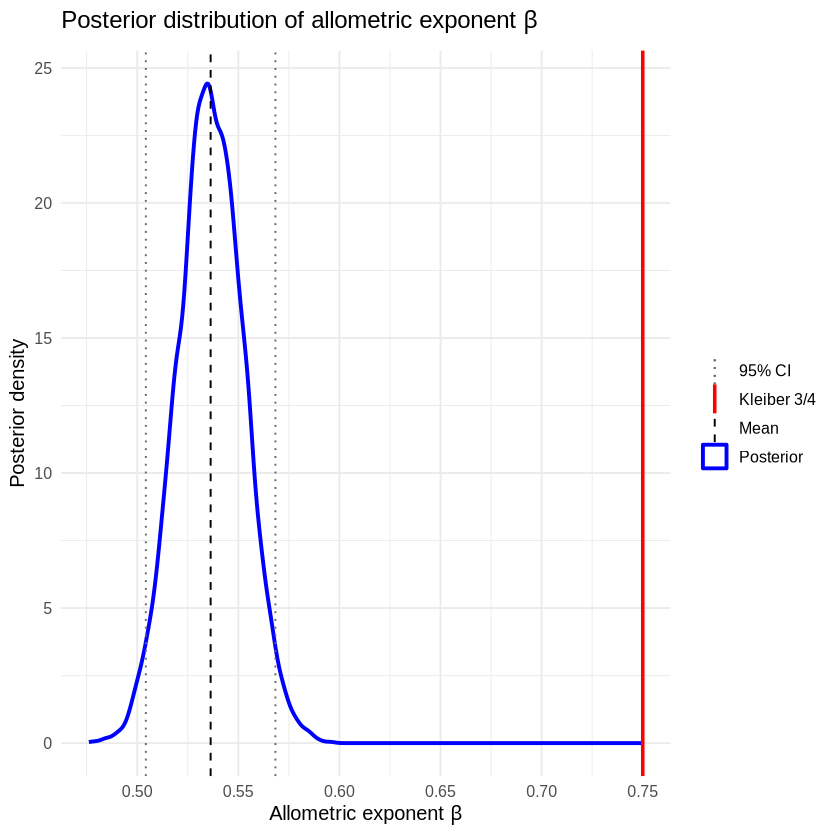

In [22]:
# 3. QUESTION 2 - free-exponent model (Model 2)               #

# y = alpha + beta * x + noise ; beta is the exponent we infer.
jags_model <- "
model {
  for (i in 1:N) {
    mu[i] <- alpha + beta * x[i]
    y[i]  ~ dnorm(mu[i], tau)
  }
  alpha ~ dnorm(0, 0.0001)   
  beta  ~ dnorm(0, 0.0001)   
  sigma ~ dunif(0, 100)
  tau  <- 1 / (sigma * sigma) # JAGS uses precision = 1/sigma^2
}
"

jags_data <- list(N = nrow(data), x = data$log_mass, y = data$log_rate)

model <- jags.model(textConnection(jags_model), data = jags_data, n.chains = 3)
update(model, 1000)
samples <- coda.samples(model, variable.names = c("alpha", "beta", "sigma"),
                        n.iter = 5000)

# posterior summary + convergence
cat("\n--- Posterior summary (Model 2) ---\n")
print(summary(samples))

cat("\n--- Convergence diagnostics ---\n")
print(gelman.diag(samples))   
print(effectiveSize(samples)) 

# ---- the Q2 headline numbers ----
beta_draws <- as.matrix(samples)[, "beta"]

#  QUESTION 2 figure - posterior of beta                        

beta_mean <- mean(beta_draws)
ci        <- quantile(beta_draws, c(0.025, 0.975))

p_beta <- ggplot(data.frame(beta = beta_draws), aes(x = beta)) +
  geom_density(aes(color = "Posterior"), linewidth = 1.1) +
  geom_vline(aes(xintercept = beta_mean, color = "Mean"),   linetype = "dashed") +
  geom_vline(aes(xintercept = ci[1],     color = "95% CI"), linetype = "dotted") +
  geom_vline(aes(xintercept = ci[2],     color = "95% CI"), linetype = "dotted") +
  geom_vline(aes(xintercept = 0.75,      color = "Kleiber 3/4"), linewidth = 1) +
  scale_color_manual(name = NULL,
                     values = c("Posterior" = "blue", "Mean" = "black",
                                "95% CI" = "grey40", "Kleiber 3/4" = "red")) +
  labs(x = expression("Allometric exponent " * beta),
       y = "Posterior density",
       title = expression("Posterior distribution of allometric exponent " * beta)) +
  theme_minimal(base_size = 12)

print(p_beta)
ggsave("q2_beta_posterior.pdf", p_beta, width = 8, height = 5)
cat("\n--- QUESTION 2 result: exponent beta ---\n")
print(quantile(beta_draws, c(0.025, 0.5, 0.975)))  


save(samples, model, data, file = "q1_q2_results.RData")
cat("\nSaved: q1_scatter.pdf  and  q1_q2_results.RData\n")

## 3. Compute the posterior probability $P(\beta > 3/4 \mid \text{data})$ and report whether Kleiber’s exponent is inside the 95% credible interval.

In [23]:
# 3. QUESTION 3 - Posterior probability P(beta > 3/4 | data)

# 1. To compute the posterior probability we use a trick: we compute the mean. In fact, what we get is a fraction: the denominator is
#    the total number of samples from the MCMC; the numerator is the number of samples from the MCMC that satisfy the condition beta > 3/4.
#    This is our estimate of the posterior probability P(beta > 3/4 | data)

prob_kleiber <- mean(beta_draws > 0.75)

# 2. 
is_inside_ci <- (0.75 >= ci[1] && 0.75 <= ci[2])

# Print
cat("\n--- Point 3 - Results ---\n")
cat("1. Posterior probability: P(beta > 3/4 | data) = ", prob_kleiber, "\n")
cat("2. Lower limit 95% CI:", ci[1], "\n")
cat("3. Upper limit 95% CI:", ci[2], "\n")
cat("4. Is Kleiber's exponent 0.75 within the 95% CI?", ifelse(is_inside_ci, "Yes", "No"), "\n")


--- Point 3 - Results ---
1. Posterior probability: P(beta > 3/4 | data) =  0 
2. Lower limit 95% CI: 0.504253 
3. Upper limit 95% CI: 0.5683301 
4. Is Kleiber's exponent 0.75 within the 95% CI? No 


## 4. Models Comparison

### Samplers diagnostic

In [24]:
# Prepare the data
# Ensure class_id is numeric: 1 = Aves, 2 = Mammalia
data$class_id <- as.numeric(as.factor(data$class))

# Data list for Models 1 and 2
data_jags <- list(
  x = data$log_mass,
  y = data$log_rate,
  N = nrow(data)
)

# Data list for Model 3 (adds the group vector 'g')
data_jags_group <- list(
  x = data$log_mass,
  y = data$log_rate,
  g = data$class_id,
  N = nrow(data)
)

### THESE MODELS HAVE DIFFERENT SIGMA COMPARED TO THE MODEL AT POINT 2
### Also, the model precision is too spread, 0.0001 means sd 100.

# Define the JAGS models
model_string_1 <- "
model {
  for (i in 1:N) {
    y[i] ~ dnorm(mu[i], tau)
    mu[i] <- alpha + 0.75 * x[i]
  }
  alpha ~ dnorm(0, 0.0001)
  sigma ~ dunif(0, 10)
  tau <- 1 / (sigma * sigma)
}
"

model_string_2 <- "
model {
  for (i in 1:N) {
    y[i] ~ dnorm(mu[i], tau)
    mu[i] <- alpha + beta * x[i]
  }
  alpha ~ dnorm(0, 0.0001)
  beta ~ dnorm(0, 0.0001)
  sigma ~ dunif(0, 10)
  tau <- 1 / (sigma * sigma)
}
"

model_string_3 <- "
model {
  for (i in 1:N) {
    y[i] ~ dnorm(mu[i], tau)
    mu[i] <- alpha[g[i]] + beta[g[i]] * x[i]
  }
  for (j in 1:2) {
    alpha[j] ~ dnorm(0, 0.0001)
    beta[j] ~ dnorm(0, 0.0001)
  }
  sigma ~ dunif(0, 10)
  tau <- 1 / (sigma * sigma)
}
"

# Initialize and sample models with low adaptation and no burn-in to find ideal one
n_iter_sample <- 5000

jags_model_1 <- jags.model(textConnection(model_string_1), data = data_jags, n.chains = 3, n.adapt = 1, quiet = TRUE)
samples_1 <- coda.samples(jags_model_1, variable.names = c("alpha"), n.iter = n_iter_sample)

jags_model_2 <- jags.model(textConnection(model_string_2), data = data_jags, n.chains = 3, n.adapt = 1, quiet = TRUE)
samples_2 <- coda.samples(jags_model_2, variable.names = c("alpha", "beta"), n.iter = n_iter_sample)

jags_model_3 <- jags.model(textConnection(model_string_3), data = data_jags_group, n.chains = 3, n.adapt = 1, quiet = TRUE)
samples_3 <- coda.samples(jags_model_3, variable.names = c("alpha", "beta"), n.iter = n_iter_sample)

Warning message in jags.model(textConnection(model_string_1), data = data_jags, :
“Adaptation incomplete”


NOTE: Stopping adaptation




Warning message in jags.model(textConnection(model_string_2), data = data_jags, :
“Adaptation incomplete”


NOTE: Stopping adaptation




Warning message in jags.model(textConnection(model_string_3), data = data_jags_group, :
“Adaptation incomplete”


NOTE: Stopping adaptation




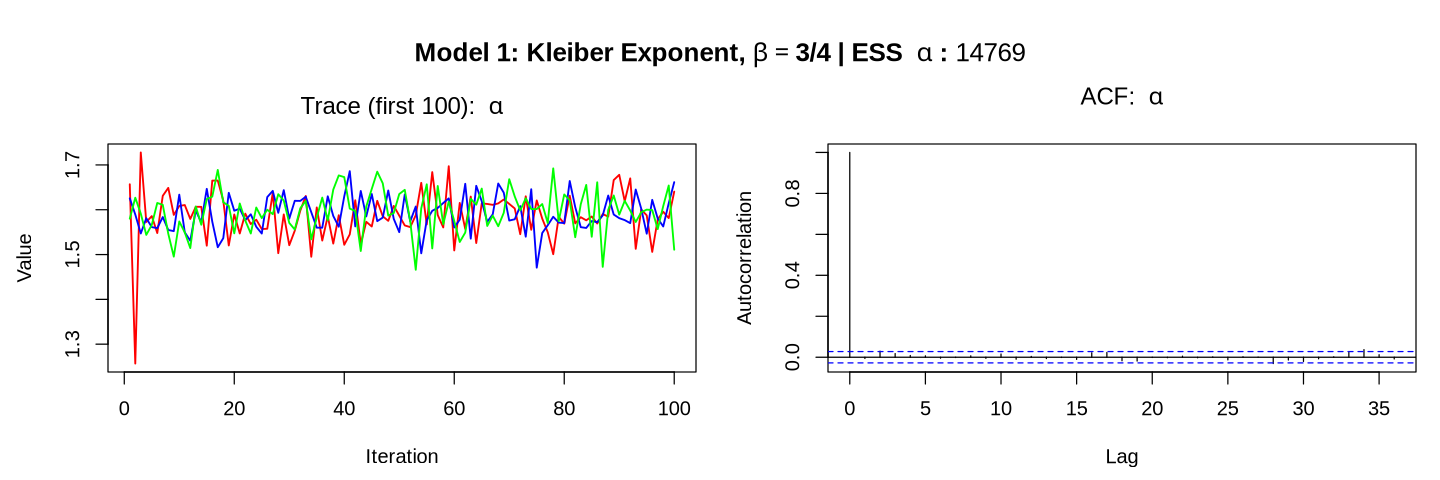

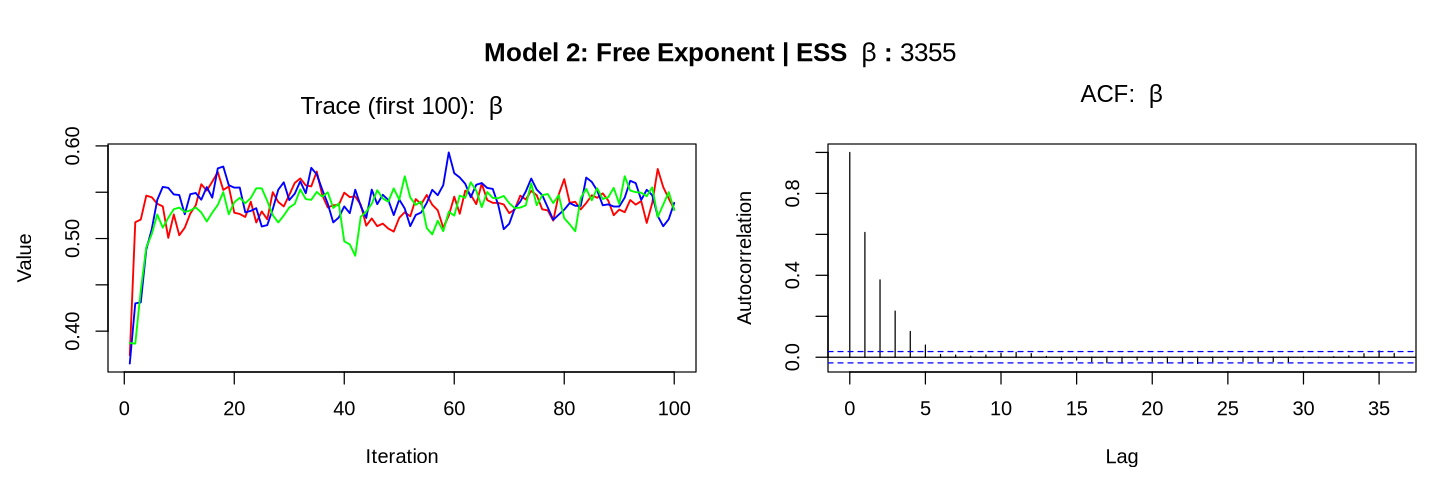

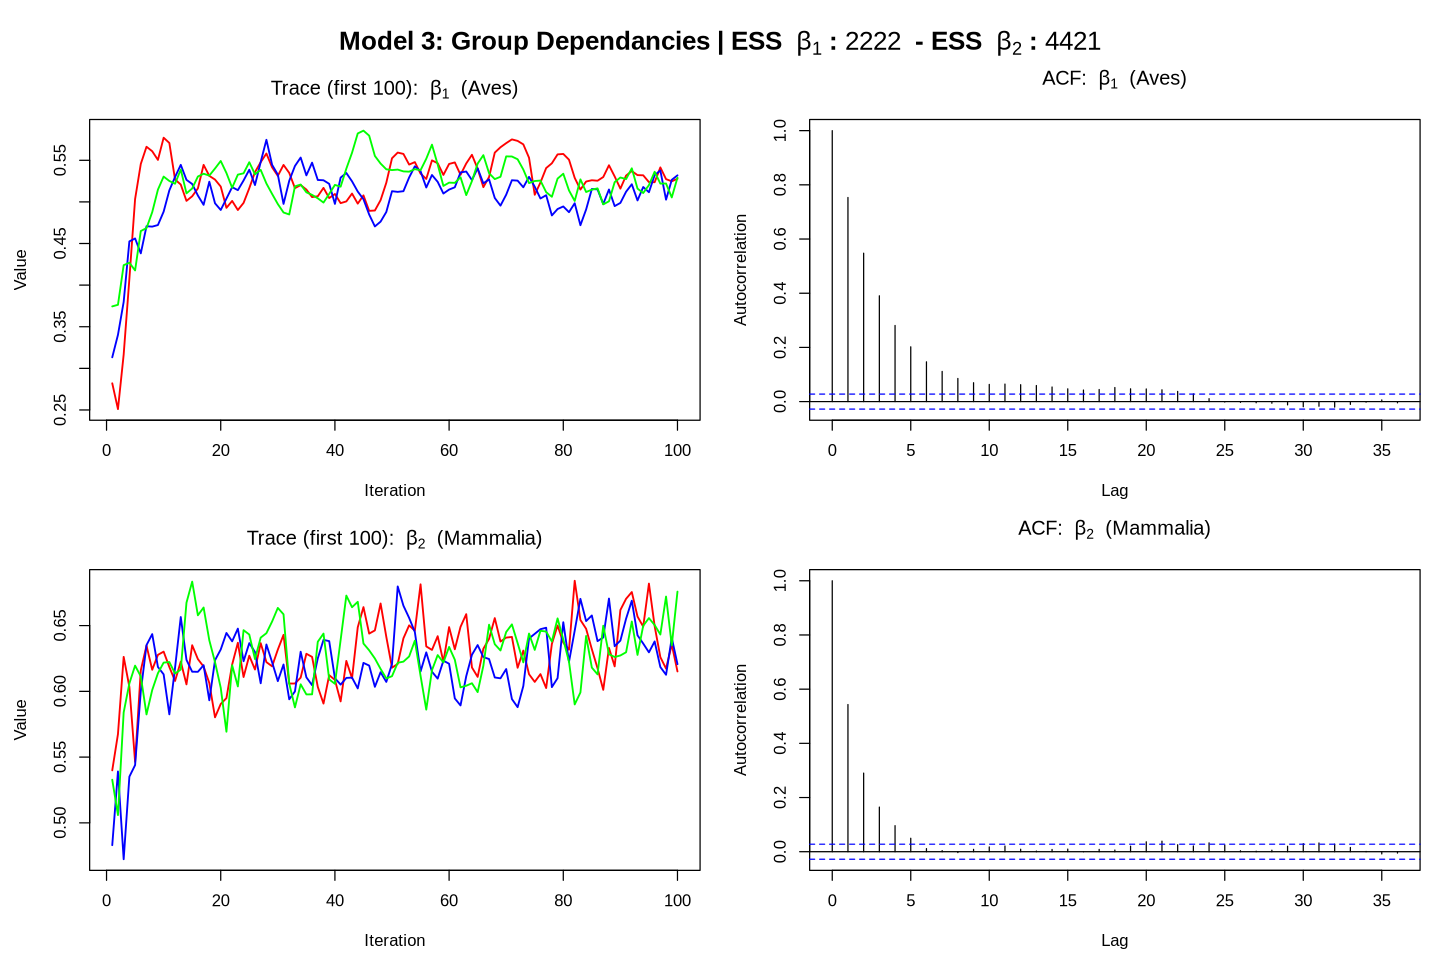

In [25]:
# Set base canvas size for 1-row plots
options(repr.plot.width = 12, repr.plot.height = 4)

# Helper function to plot figures
plot_early_trace <- function(samples, param_name, title_expr, n_first = 100) {
  ch1 <- samples[[1]][1:n_first, param_name]
  ch2 <- samples[[2]][1:n_first, param_name]
  ch3 <- samples[[3]][1:n_first, param_name]
  
  matplot(1:n_first, cbind(ch1, ch2, ch3), type = "l", lty = 1, lwd = 1.5,
          col = c("red", "blue", "green"),
          xlab = "Iteration", ylab = "Value", 
          main = title_expr,
          cex.main = 1.2)
}

# ---------------------------------------------------------
# MODEL 1 
# ---------------------------------------------------------
par(mfrow = c(1, 2), mar = c(4.5, 4.5, 3, 1), oma = c(0, 0, 3, 0))

ess_m1 <- round(effectiveSize(samples_1)[["alpha"]])

# Trace
plot_early_trace(samples_1, "alpha", expression("Trace (first 100): " ~ alpha))

# ACF
acf(samples_1[[1]][, "alpha"], main = expression("ACF: " ~ alpha), ylab = "Autocorrelation", cex.main = 1.2)

# bquote() mixes text, Greek letters (~ alpha), and dynamic variables (.())
mtext(bquote(bold("Model 1: Kleiber Exponent," ~ beta == "3/4 | ESS " ~ alpha ~ ":" ~ .(ess_m1))), outer = TRUE, cex = 1.3)# ---------------------------------------------------------
# MODEL 2 
# ---------------------------------------------------------
par(mfrow = c(1, 2), mar = c(4.5, 4.5, 3, 1), oma = c(0, 0, 3, 0))

ess_m2_b <- round(effectiveSize(samples_2)[["beta"]])

# Trace
plot_early_trace(samples_2, "beta", expression("Trace (first 100): " ~ beta))

# ACF
acf(samples_2[[1]][, "beta"], main = expression("ACF: " ~ beta), ylab = "Autocorrelation", cex.main = 1.2)

mtext(bquote(bold("Model 2: Free Exponent | ESS " ~ beta ~ ":" ~ .(ess_m2_b))), outer = TRUE, cex = 1.3)
# ---------------------------------------------------------
# MODEL 3 
# ---------------------------------------------------------
# Increase canvas height for 2 rows
options(repr.plot.height = 8)
par(mfrow = c(2, 2), mar = c(4.5, 4.5, 3, 1), oma = c(0, 0, 3, 0))

ess_m3_b1 <- round(effectiveSize(samples_3)[["beta[1]"]])
ess_m3_b2 <- round(effectiveSize(samples_3)[["beta[2]"]])

# Row 1: beta[1]
plot_early_trace(samples_3, "beta[1]", expression("Trace (first 100): " ~ beta[1] ~ " (Aves)"))
acf(samples_3[[1]][, "beta[1]"], main = expression("ACF: " ~ beta[1] ~ " (Aves)"), ylab = "Autocorrelation", cex.main = 1.2)

# Row 2: beta[2]
plot_early_trace(samples_3, "beta[2]", expression("Trace (first 100): " ~ beta[2] ~ " (Mammalia)"))
acf(samples_3[[1]][, "beta[2]"], main = expression("ACF: " ~ beta[2] ~ " (Mammalia)"), ylab = "Autocorrelation", cex.main = 1.2)

mtext(bquote(bold("Model 3: Group Dependancies | ESS " ~ beta[1] ~ ":" ~ .(ess_m3_b1) ~ " - ESS " ~ beta[2] ~ ":" ~ .(ess_m3_b2))), outer = TRUE, cex = 1.3)
# ---------------------------------------------------------
# Reset plotting layout to default for further plots
# ---------------------------------------------------------
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1, oma = c(0, 0, 0, 0))
options(repr.plot.width = 7, repr.plot.height = 7)

A reasonable burn-in of 100 iterations can be recovered qualitatively from these plots. We focused only on the beta parameters being the main focus of our work. The traces for the intercept alpha is shown solely for Model 1 (Kleiber's Model). In the following section we initialize the actual sampler with the burn-in found and 500 adapatation iterations.

### Samplers Initialization

In [26]:
# Set MCMC parameters based on previous diagnostic
n_adapt_steps <- 500
n_burn_in     <- 100
n_iter_sample <- 5000

# ---------------------------------------------------------
# MODEL 1: KLEIBER (Fixed Exponent)
# ---------------------------------------------------------
jags_model_1 <- jags.model(textConnection(model_string_1), 
                           data = data_jags, 
                           n.chains = 3, 
                           n.adapt = n_adapt_steps, 
                           quiet = TRUE)

update(jags_model_1, n.iter = n_burn_in)

samples_1 <- coda.samples(jags_model_1, 
                          variable.names = c("alpha", "sigma"), 
                          n.iter = n_iter_sample)

# ---------------------------------------------------------
# MODEL 2: FREE EXPONENT
# ---------------------------------------------------------
jags_model_2 <- jags.model(textConnection(model_string_2), 
                           data = data_jags, 
                           n.chains = 3, 
                           n.adapt = n_adapt_steps, 
                           quiet = TRUE)

update(jags_model_2, n.iter = n_burn_in)

samples_2 <- coda.samples(jags_model_2, 
                          variable.names = c("alpha", "beta", "sigma"), 
                          n.iter = n_iter_sample)

# ---------------------------------------------------------
# MODEL 3: GROUP-DEPENDENT SCALING
# ---------------------------------------------------------
jags_model_3 <- jags.model(textConnection(model_string_3), 
                           data = data_jags_group, 
                           n.chains = 3, 
                           n.adapt = n_adapt_steps, 
                           quiet = TRUE)

update(jags_model_3, n.iter = n_burn_in)

samples_3 <- coda.samples(jags_model_3, 
                          variable.names = c("alpha", "beta", "sigma"), 
                          n.iter = n_iter_sample)

### Models Comparison

In [27]:
# Compute DIC for all models
dic_1 <- dic.samples(jags_model_1, n.iter = n_iter_sample)
dic_2 <- dic.samples(jags_model_2, n.iter = n_iter_sample)
dic_3 <- dic.samples(jags_model_3, n.iter = n_iter_sample)

# Extract total DIC (Deviance + Penalty)
dic_val_1 <- sum(dic_1$deviance) + sum(dic_1$penalty)
dic_val_2 <- sum(dic_2$deviance) + sum(dic_2$penalty)
dic_val_3 <- sum(dic_3$deviance) + sum(dic_3$penalty)

# Extract Max Gelman-Rubin (R-hat) to summarize convergence
# (We take the max R-hat across all parameters for the given model)
rhat_1 <- max(gelman.diag(samples_1)$psrf[, 1])
rhat_2 <- max(gelman.diag(samples_2)$psrf[, 1])
rhat_3 <- max(gelman.diag(samples_3)$psrf[, 1])

# Extract Min Effective Sample Size (ESS) to summarize mixing
# (We take the lowest ESS across all parameters)
ess_1 <- min(effectiveSize(samples_1))
ess_2 <- min(effectiveSize(samples_2))
ess_3 <- min(effectiveSize(samples_3))

# Evaluate the mean of models parameters
mean_alpha_1 <- mean(samples_1[[1]][, "alpha"])
mean_beta_2  <- mean(samples_2[[1]][, "beta"])
mean_b1_3    <- mean(samples_3[[1]][, "beta[1]"])
mean_b2_3    <- mean(samples_3[[1]][, "beta[2]"])

# Descriptive strings for summary
params_summary_1 <- paste0("alpha = ", round(mean_alpha_1, 3))
params_summary_2 <- paste0("beta = ", round(mean_beta_2, 3))
params_summary_3 <- paste0("b1(Aves)=", round(mean_b1_3, 3), ", b2(Mam)=", round(mean_b2_3, 3))

# Create a Summary Dataframe
summary_table <- data.frame(
  Model = c("1. Kleiber (Fixed 0.75)", "2. Free Exponent", "3. Group-Dependent"),
  DIC = round(c(dic_val_1, dic_val_2, dic_val_3), 2),
  Max_R_hat = round(c(rhat_1, rhat_2, rhat_3), 3),
  Min_ESS = round(c(ess_1, ess_2, ess_3), 0),
  Estimated_Means = c(params_summary_1, params_summary_2, params_summary_3)
)

# Print the table
cat("\n====================================================================================\n")
cat("                       MODELS COMPARISON & PARAMETERS SUMMARY                       \n")
cat("====================================================================================\n")
print(summary_table, row.names = FALSE, right = FALSE)
cat("====================================================================================\n")


                       MODELS COMPARISON & PARAMETERS SUMMARY                       
 Model                   DIC    Max_R_hat Min_ESS Estimated_Means              
 1. Kleiber (Fixed 0.75) 570.83 1.001     9215    alpha = 1.594                
 2. Free Exponent        438.54 1.003     3342    beta = 0.536                 
 3. Group-Dependent      365.86 1.001     2185    b1(Aves)=0.527, b2(Mam)=0.629


Even in this case we focus only on the beta parameters (the mean of the intecept for model 2 and 3 can be added). The best model is the third one, having the lowest DIC. We used min() and max() functions for ESS and Gelma-Rubin metric respectively, considering that they evaluate these quantities for every parameter involved in the model (for Model 3 the effectiveSie() function evaluates 5 ESS, one for each parameter). By taking the min() out of the list of ESS of the model we take the "worst" value. If the worst is still a high enough number it means our model is healthy. Same goes for the Gelman-Rubin metric (this time lower is better so we take the max()). Maybe it will be beneficial to plot the posterior distributions of Model 3's exponents in the final paper.

## 5. Produce posterior predictive bands for metabolic rate over the observed body-mass range.

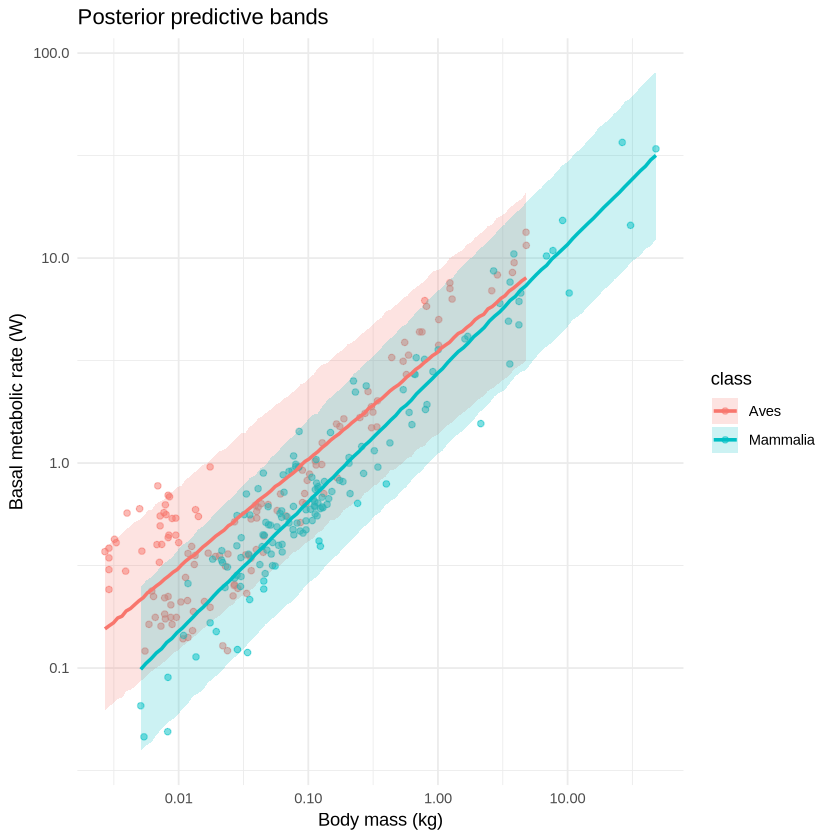

In [30]:
#using MCMC chain of model 3, each row (?) of the matrix is a posterior draw
post3 <- as.matrix(samples_3)


# aves mass grid
mass_aves <- exp(seq(
                log(min(data$body_mass[data$class == "Aves"])),
                log(max(data$body_mass[data$class == "Aves"])),
                length.out = 100)
             )

# this function takes 
pred_aves <- sapply(log(mass_aves), function(x){
                    mu <- post3[, "alpha[1]"] + post3[, "beta[1]"] * x
                    rnorm(n = nrow(post3), mean = mu, sd = post3[, "sigma"])
                                    }
             )

pred_aves <- exp(pred_aves)

aves_band <- data.frame(
                body_mass = mass_aves,
                median = apply(pred_aves, 2, median),
                lower = apply(pred_aves, 2, quantile, probs = 0.025),
                upper = apply(pred_aves, 2, quantile, probs = 0.975),
                class = "Aves"
             )


# mammalia
mass_mammalia <- exp(seq(
                    log(min(data$body_mass[data$class == "Mammalia"])),
                    log(max(data$body_mass[data$class == "Mammalia"])),
                    length.out = 100)
                )

pred_mammalia <- sapply(log(mass_mammalia), function(x){
                        mu <- post3[, "alpha[2]"] + post3[, "beta[2]"] * x
                        rnorm(n = nrow(post3), mean = mu, sd = post3[, "sigma"])
                                        }
                )

pred_mammalia <- exp(pred_mammalia)

mammalia_band <- data.frame(
                    body_mass = mass_mammalia,
                    median = apply(pred_mammalia, 2, median),
                    lower = apply(pred_mammalia, 2, quantile, probs = 0.025),
                    upper = apply(pred_mammalia, 2, quantile, probs = 0.975),
                    class = "Mammalia"
                )


predictive_bands <- bind_rows(aves_band, mammalia_band)


pred_band <- ggplot() + geom_point(data = data, aes(x = body_mass, y = metabolic_rate, color = class), alpha = 0.5) +
            geom_ribbon(data = predictive_bands,aes(x = body_mass, ymin = lower, ymax = upper, fill = class), alpha = 0.2) +
            geom_line(data = predictive_bands, aes(x = body_mass, y = median, color = class), linewidth = 1) +
            scale_x_log10() + scale_y_log10() +
            labs(x = "Body mass (kg)", y = "Metabolic rate (W)", title = "Posterior predictive bands") +
            theme_minimal()

pred_band

#ggsave("q5_posterior_predictive_bands.pdf", pred_band, width = 8, height = 5)

## 6. Predict the metabolic rate of an animal with mass M = 1 kg, including posterior uncertainty.

In [29]:
pred_aves_1kg <- rnorm(n = nrow(post3), mean = post3[, "alpha[1]"], sd = post3[, "sigma"])
pred_aves_1kg <- exp(pred_aves_1kg)


pred_mammalia_1kg <- rnorm(n = nrow(post3), mean = post3[, "alpha[2]"], sd = post3[, "sigma"])
pred_mammalia_1kg <- exp(pred_mammalia_1kg)


prediction_1kg <- data.frame(class = c("Aves", "Mammalia"), 
                             median_W = c(median(pred_aves_1kg), median(pred_mammalia_1kg)),
                             lower_95_W = c(quantile(pred_aves_1kg, 0.025), quantile(pred_mammalia_1kg, 0.025)),
                             upper_95_W = c(quantile(pred_aves_1kg, 0.975), quantile(pred_mammalia_1kg, 0.975) )
                    )

print(prediction_1kg

     class median_W lower_95_W upper_95_W
1     Aves 3.484304   1.404353   8.822776
2 Mammalia 2.769119   1.086863   6.899318
